Simple data-exploration to get a feel for the histogram of the players

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import nbinom
from scipy.optimize import minimize

Master dictionary created.

Sorting players and identifying top performers by position...
Top 5 Forwards: ['Erling Haaland', 'Ollie Watkins', 'Alexander Isak', 'Ivan Toney', 'Callum Wilson']
Top 5 Midfielders: ['Mohamed Salah', 'Bukayo Saka', 'Kevin De Bruyne', 'Phil Foden', 'Martin Ødegaard']
Top 5 Defenders: ['Kieran Trippier', 'Conor Bradley', 'Benjamin White', 'Joško Gvardiol', 'William Saliba']
Median 5 Players: ['Matt Turner', 'Jeffrey Schlupp', 'Cameron Archer', 'Joel Ward', 'Vitaly Janelt']
Displaying plots. Close the plot window to end the script.


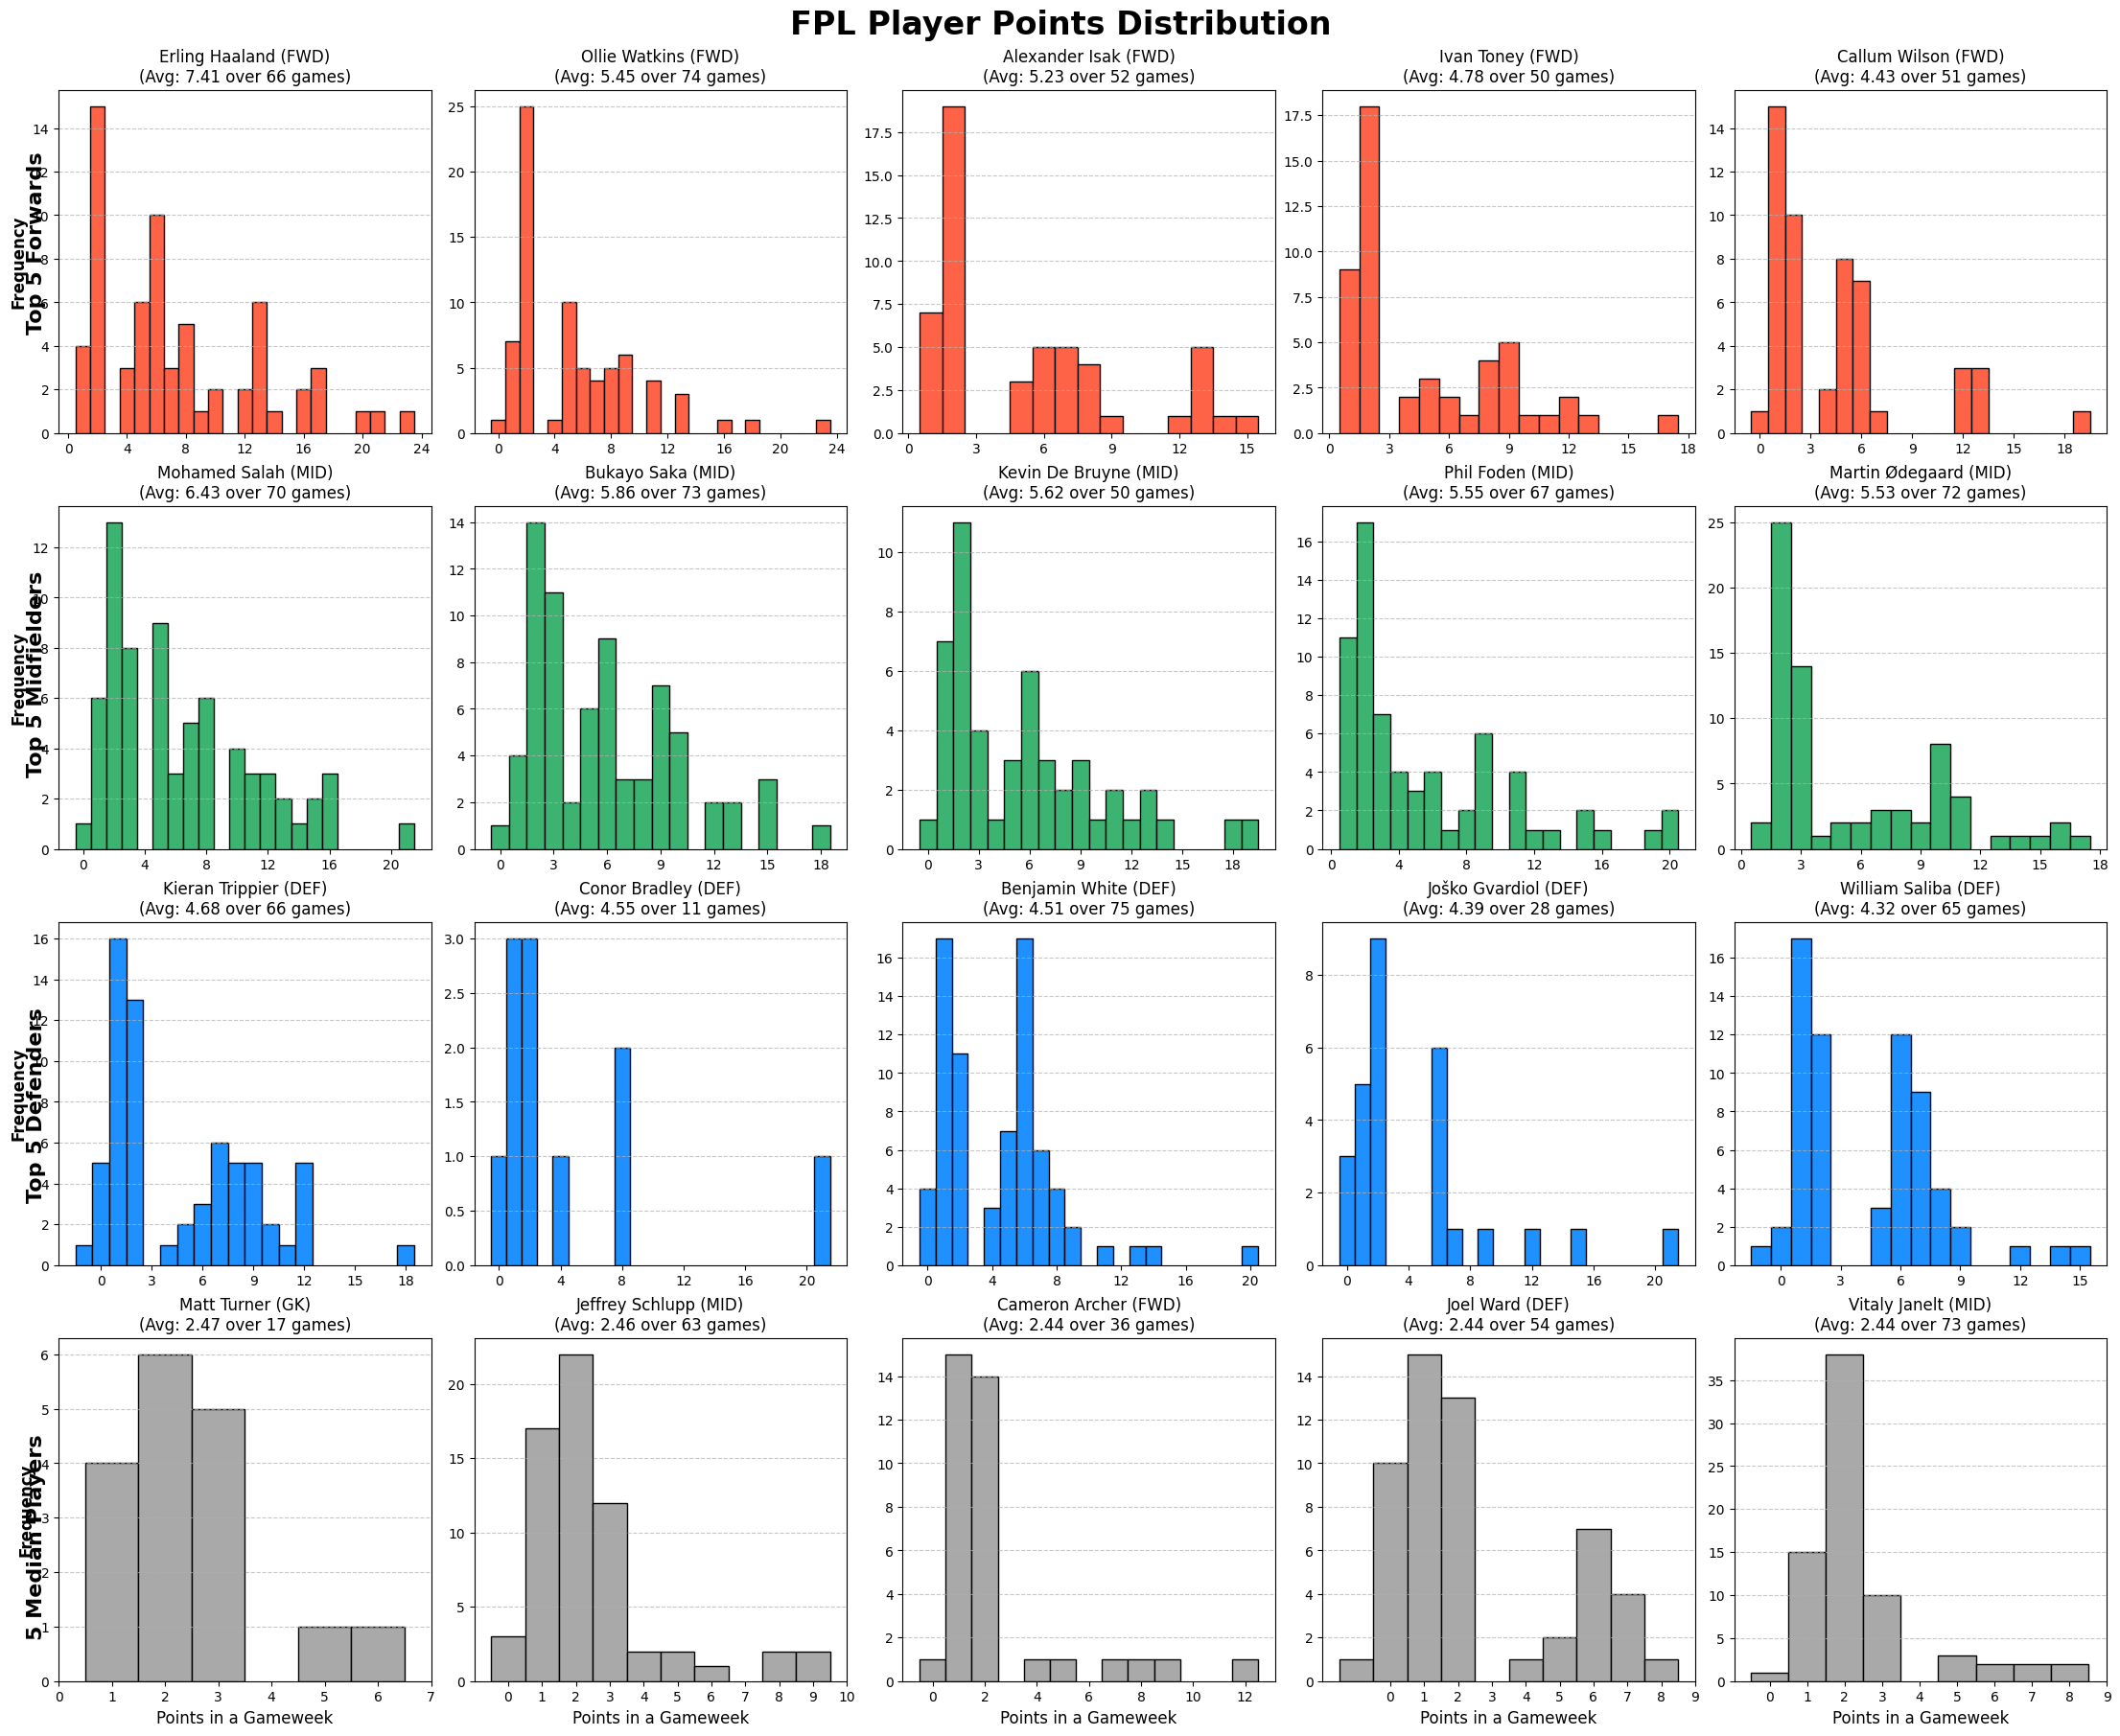

In [2]:
# We now need the 'position' column to filter players
histogram_features = ['name', 'total_points', 'position', 'minutes']

try:
    # Loading data from previous seasons
    df_22_23 = pd.read_csv("../data/historic_data/2022-23/gws/merged_gw.csv", usecols=histogram_features)
    df_23_24 = pd.read_csv("../data/historic_data/2023-24/gws/merged_gw.csv", usecols=histogram_features)

    # Getting players for the upcoming season
    df_25_26_names = pd.read_csv("../data/player_idlist.csv")
    df_25_26_names['name'] = df_25_26_names['first_name'] + " " + df_25_26_names['second_name']
    current_players = set(df_25_26_names['name'])

except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please ensure your file paths are correct. Exiting.")
    exit()

# Combine all historical data into a single DataFrame
# For now, using only the two seasons provided in your non-working code
df_all_seasons = pd.concat([df_22_23, df_23_24], ignore_index=True)
df_all_seasons = df_all_seasons[df_all_seasons['minutes'] > 0]

# Filter for players active in the upcoming season
df_filtered = df_all_seasons[df_all_seasons['name'].isin(current_players)].copy()

# Create the Points Occurrence Dictionary 
point_counts = df_filtered.groupby(['name', 'total_points']).size()

player_histogram_dict = {}
for (name, points), count in point_counts.items():
    player_histogram_dict.setdefault(name, {})[points] = count

print("Master dictionary created.")

# Sort Players and Identify Top by Position 
print("\nSorting players and identifying top performers by position...")

# Calculate base statistics (mean, count) for each player
player_stats = df_filtered.groupby('name')['total_points'].agg(['mean', 'count']).rename(columns={'mean': 'average_score'})

# Determine each player's primary position (most frequent one)
# This handles cases where a player might have changed positions
player_primary_position = df_filtered.groupby('name')['position'].agg(lambda x: x.mode()[0])

# Combine stats with position information
player_stats = player_stats.join(player_primary_position)

# Sort the combined stats DataFrame by average score
sorted_stats = player_stats.sort_values('average_score', ascending=False)

# Identify the top 5 players for each position from the sorted list
top_5_fwd = sorted_stats[sorted_stats['position'] == 'FWD'].head(5).index.tolist()
top_5_mid = sorted_stats[sorted_stats['position'] == 'MID'].head(5).index.tolist()
top_5_def = sorted_stats[sorted_stats['position'] == 'DEF'].head(5).index.tolist()

# Identify the 5 median players from the overall sorted list
sorted_player_names = sorted_stats.index.tolist()
n_players = len(sorted_player_names)
median_index = n_players // 2
median_5_players = sorted_player_names[median_index - 2 : median_index + 3]

print("Top 5 Forwards:", top_5_fwd)
print("Top 5 Midfielders:", top_5_mid)
print("Top 5 Defenders:", top_5_def)
print("Median 5 Players:", median_5_players)


def plot_player_histogram(ax, player_name, player_data, stats_df, color='skyblue'):
    """Plots a histogram for a single player on a given axes object."""
    points_data = player_data.get(player_name)
    if not points_data or player_name not in stats_df.index:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
        ax.set_title(f"{player_name}\n(No Data)")
        ax.set_xticks([])
        ax.set_yticks([])
        return
        
    points = sorted(points_data.keys())
    counts = [points_data[p] for p in points]
    
    avg_score = stats_df.loc[player_name, 'average_score']
    games_played = stats_df.loc[player_name, 'count']
    position = stats_df.loc[player_name, 'position']
    
    ax.bar(points, counts, color=color, edgecolor='black', width=1.0)
    ax.set_title(f"{player_name} ({position})\n(Avg: {avg_score:.2f} over {int(games_played)} games)")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    max_point = max(points) if points else 0
    ax.set_xticks(np.arange(0, max_point + 2, step=max(1, (max_point // 5))))

# Create a 4x5 grid for the plots
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(22, 18), constrained_layout=True)
fig.suptitle('FPL Player Points Distribution', fontsize=24, weight='bold')

# Plotting each category on its own row 
categories = {
    'Top 5 Forwards': (top_5_fwd, 'tomato'),
    'Top 5 Midfielders': (top_5_mid, 'mediumseagreen'),
    'Top 5 Defenders': (top_5_def, 'dodgerblue'),
    '5 Median Players': (median_5_players, 'darkgray')
}

for row_index, (title, (player_list, color)) in enumerate(categories.items()):
    # Add a row title
    axes[row_index, 0].set_ylabel("Frequency", fontsize=12, weight='bold')
    fig.text(0.01, (3.45 - row_index) / 4.0, title, va='center', rotation='vertical', fontsize=16, weight='bold')

    for col_index, player_name in enumerate(player_list):
        plot_player_histogram(axes[row_index, col_index], player_name, player_histogram_dict, sorted_stats, color=color)

# Set common X-label for the last row
for ax in axes[3]:
    ax.set_xlabel("Points in a Gameweek", fontsize=12)

print("Displaying plots. Close the plot window to end the script.")
plt.show()

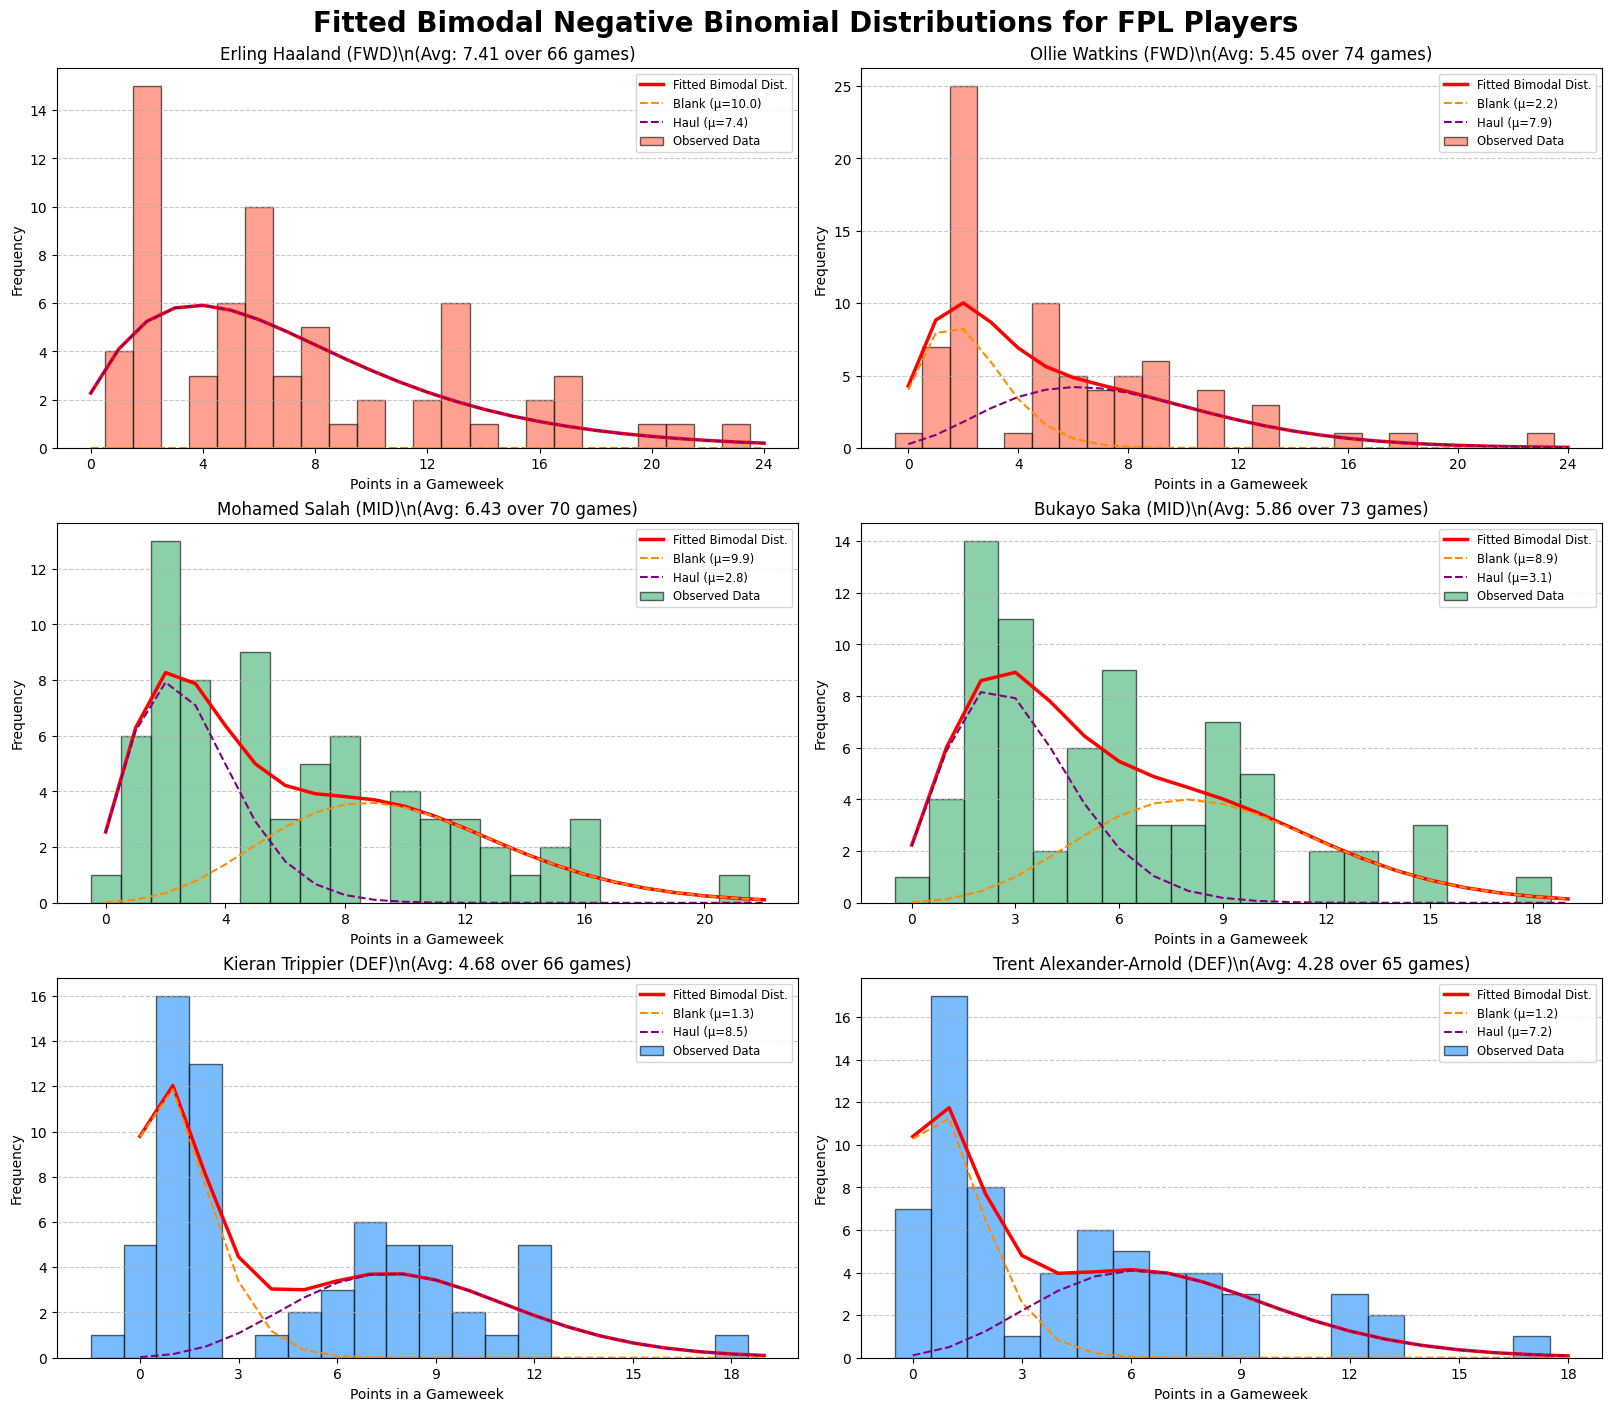

In [ ]:
def negative_bimodal_pmf(x, w, mu1, alpha1, mu2, alpha2):
    """
    Probability Mass Function (PMF) for a bimodal negative binomial distribution.
    Scipy's nbinom uses n (size/alpha) and p (prob). We convert from mu and alpha.
    """
    # PMF of the first component ("blank" scores)
    p1 = alpha1 / (alpha1 + mu1)
    pmf1 = nbinom.pmf(x, n=alpha1, p=p1)
    
    # PMF of the second component ("haul" scores)
    p2 = alpha2 / (alpha2 + mu2)
    pmf2 = nbinom.pmf(x, n=alpha2, p=p2)
    
    # Combine the two distributions with the weight
    return (1 - w) * pmf1 + w * pmf2

def neg_log_likelihood(params, data):
    """
    Objective function for the optimizer: the negative log-likelihood.
    We want to minimize this function to find the best parameters.
    """
    w, mu1, alpha1, mu2, alpha2 = params
    
    # Calculate the probability of each observed data point
    probabilities = negative_bimodal_pmf(data, w, mu1, alpha1, mu2, alpha2)
    
    # To avoid log(0) errors, add a very small constant
    probabilities[probabilities <= 0] = 1e-9
    
    # Return the negative sum of log probabilities
    return -np.sum(np.log(probabilities))

# --- Part 3: Fitting and Plotting ---

def fit_and_plot(ax, player_name, player_data, stats_df, color='skyblue'):
    """
    Fits the bimodal model to a player's data and plots it on a given axes.
    """
    points_data = player_data.get(player_name)
    if not points_data or player_name not in stats_df.index:
        ax.set_title(f"{player_name}\\n(No Data)")
        return

    # 1. Plot the original histogram
    points = np.array(list(points_data.keys()))
    counts = np.array(list(points_data.values()))
    total_games = sum(counts)
    
    ax.bar(points, counts, color=color, edgecolor='black', width=1.0, alpha=0.6, label='Observed Data')
    
    # 2. Prepare data for fitting
    # Expand the histogram into a full data array for the likelihood function
    observed_scores = np.repeat(points, counts)

    # 3. Fit the model using optimization
    # Initial guesses for the parameters [w, mu1, alpha1, mu2, alpha2]
    initial_guess = [0.3, 2.5, 1.0, 8.0, 2.0]
    
    # Bounds to ensure parameters are valid (e.g., probabilities 0-1, others > 0)
    bounds = [(0, 1), (0.1, 10), (0.1, 20), (1, 25), (0.1, 20)]

    result = minimize(
        neg_log_likelihood,
        initial_guess,
        args=(observed_scores),
        bounds=bounds,
        method='L-BFGS-B' # A good choice for bounded optimization
    )
    
    # Extract the best-fit parameters
    w_fit, mu1_fit, alpha1_fit, mu2_fit, alpha2_fit = result.x

    # 4. Plot the fitted distribution
    x_plot = np.arange(0, max(points) + 2)
    
    # Get the overall fitted PMF and scale it to match the histogram frequency
    fitted_pmf = negative_bimodal_pmf(x_plot, w_fit, mu1_fit, alpha1_fit, mu2_fit, alpha2_fit)
    ax.plot(x_plot, fitted_pmf * total_games, color='red', linewidth=2.5, label='Fitted Bimodal Dist.')
    
    # Plot the individual components
    p1 = alpha1_fit / (alpha1_fit + mu1_fit)
    comp1_pmf = (1 - w_fit) * nbinom.pmf(x_plot, n=alpha1_fit, p=p1)
    ax.plot(x_plot, comp1_pmf * total_games, color='darkorange', linestyle='--', label=f'Blank (μ={mu1_fit:.1f})')
    
    p2 = alpha2_fit / (alpha2_fit + mu2_fit)
    comp2_pmf = w_fit * nbinom.pmf(x_plot, n=alpha2_fit, p=p2)
    ax.plot(x_plot, comp2_pmf * total_games, color='purple', linestyle='--', label=f'Haul (μ={mu2_fit:.1f})')
    
    # Final plot formatting from your notebook
    avg_score = stats_df.loc[player_name, 'average_score']
    games_played = stats_df.loc[player_name, 'count']
    position = stats_df.loc[player_name, 'position']
    ax.set_title(f"{player_name} ({position})\\n(Avg: {avg_score:.2f} over {int(games_played)} games)")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_xticks(np.arange(0, max(points) + 2, step=max(1, (max(points) // 5))))
    ax.legend(fontsize='small')


# --- Main Execution ---
#

# Select a few key players to demonstrate the fitting process
players_to_plot = {
    'Forwards': (['Erling Haaland', 'Ollie Watkins'], 'tomato'),
    'Midfielders': (['Mohamed Salah', 'Bukayo Saka'], 'mediumseagreen'),
    'Defenders': (['Kieran Trippier', 'Trent Alexander-Arnold'], 'dodgerblue'),
}

# Create a figure to display the results
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14), constrained_layout=True)
fig.suptitle('Fitted Bimodal Negative Binomial Distributions for FPL Players', fontsize=20, weight='bold')

# Flatten the axes array for easy iteration
axes = axes.flatten()
plot_idx = 0

for category, (player_list, color) in players_to_plot.items():
    for player_name in player_list:
        if plot_idx < len(axes):
            fit_and_plot(axes[plot_idx], player_name, player_histogram_dict, sorted_stats, color=color)
            axes[plot_idx].set_xlabel("Points in a Gameweek")
            axes[plot_idx].set_ylabel("Frequency")
            plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.show()